# Criatura lendária: Esfinge
**Autor: Abraham E. G. Contreras**
### Objetivo: 
Elabore um notebook didático de Jupyter sobre um dos temas listados abaixo, seguindo as 
considerações descritas no item “Expectativas”. A entrega deve ser feita via Pull Request no repositório 
da Biblioteca Real
. A pontuação final será apenas contabilizada mediante ao aceite deste Pull Request, 
que poderá requisitar alterações adicionais após a avaliação. Veja a seção “Os enigmas da Esfinge” 
deste documento para mais informações. Houve uma tentativa de ordenar os temas abaixo do mais 
fácil para o mais difícil. Esta tentativa foi feita apenas como comodidade para o leitor atento, mas é 
importante lembrar que projetar dificuldade em uma escala de apenas uma dimensão é um processo 
que está fadado ao fracasso.
- **Estratégias para lidar com dados desbalanceados em problemas de classificação**
  
### Expectativas: É esperado que o material didático aborde o tema escolhido de forma introdutória, 
mostrando ao leitor questões fundamentais da matemática e estatística que permeiam o tema escolhido 
(caso se aplique). Imagens e gráficos ilustrativos são esperados. O notebook deve ser autocontido, 
ou seja, uma estudante que nunca ouviu falar do tema deve conseguir acompanhar e executar o 
conteúdo do início ao fim. Ser “didático” e ser “autocontido” não significa que o texto deve ser um 
texto longo, é perfeitamente possível passar a mensagem sem a necessidade de “escrever um livro”. É 
necessário também apresentar pelo menos 1 exemplo aplicado em conjunto de dado de sua escolha, 
bem como discussões comparativas com outros tópicos abordados na disciplina (por exemplo, como 
que o Gradient Boosting se difere da Floresta Aleatória?). O trabalho deve ter uma seção chamada 
“Descrição do uso de IA neste trabalho” detalhando como foi a interação com ferramentas de IA para 
a construção dos textos e códigos.

## O que são dados desbalanceados?

Dados desbalanceados ocorrem quando há uma diferença muito grande na quantidade de exemplos entre as classes de um conjunto de dados. Nesse caso, uma classe possui muito mais exemplos do que outra, o que pode dificultar o aprendizado do modelo.

Em problemas de classificação, esse desbalanceamento pode fazer com que o modelo favoreça a **classe majoritária** e tenha dificuldade para identificar a **classe minoritária**. Como resultado, o modelo pode apresentar um bom desempenho para a classe com mais exemplos, mas ter baixa capacidade de identificar corretamente os casos da classe com menos exemplos. Isso pode prejudicar a qualidade das previsões e a capacidade do modelo de funcionar bem com novos dados.

## Quais são os principais cuidados que devemos ter?

### Métricas inadequadas para dados desbalanceados

A **acurácia** pode não ser uma boa métrica para avaliar modelos treinados com dados desbalanceados. Por exemplo, se uma base possui **99% de exemplos negativos** e apenas 1% de exemplos positivos, um modelo que classifica todos os casos como negativos terá 99% de acurácia. Mesmo assim, ele não será capaz de identificar nenhum exemplo da classe positiva.

Isso mostra que uma acurácia alta não significa necessariamente que o modelo tenha um bom desempenho. Em alguns casos, o modelo pode parecer eficiente nas métricas tradicionais, mas falhar justamente na identificação da **classe minoritária**, que pode ser a mais importante para o problema.

Por isso, em conjuntos de dados desbalanceados, é importante não depender apenas da acurácia. Outras métricas, como **precisão, recall e F1-score**, podem fornecer uma visão mais completa do desempenho do modelo e mostrar melhor como ele está identificando cada classe.

### Métricas adequadas para avaliação

Para avaliar modelos com dados desbalanceados, podemos usar métricas que mostram melhor como o modelo está lidando com a **classe minoritária**.

* **Precisão (Precision):** indica, entre os casos que o modelo classificou como positivos, quantos realmente são positivos.

* **Recall:** indica, entre todos os casos que realmente são positivos, quantos o modelo conseguiu identificar corretamente. Essa métrica é importante quando não queremos deixar casos positivos passarem despercebidos.

* **F1-Score:** combina precisão e recall em uma única métrica. Por isso, é útil quando queremos avaliar as duas medidas ao mesmo tempo, principalmente em conjuntos de dados desbalanceados.

* **Matriz de Confusão:** mostra a quantidade de **verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos**. Assim, podemos entender melhor quais tipos de erro o modelo está cometendo.

Matematicamente, todas essas métricas são calculadas a partir de quatro valores da
**matriz de confusão**:

* **VP (Verdadeiro Positivo):** o modelo previu positivo e era positivo.
* **VN (Verdadeiro Negativo):** o modelo previu negativo e era negativo.
* **FP (Falso Positivo):** o modelo previu positivo, mas era negativo.
* **FN (Falso Negativo):** o modelo previu negativo, mas era positivo.

**Precisão (Precision)** mede a proporção de previsões positivas que estavam corretas:

$$
\text{Precisão} = \frac{VP}{VP+FP}
$$

Ou seja, quanto menor o número de **falsos positivos**, maior tende a ser a precisão.


**Recall** mede a proporção dos positivos reais que o modelo conseguiu encontrar:

$$
\text{Recall} = \frac{VP}{VP+FN}
$$

Aqui, o principal objetivo é reduzir os **falsos negativos**. Por isso, o recall é importante quando deixar um caso positivo passar despercebido é um problema.


**F1-Score** é a média harmônica entre precisão e recall:

$$
F1 = 2\frac{\text{Precisão}\times\text{Recall}}
{\text{Precisão}+\text{Recall}}
$$

Ele só será alto quando **precisão e recall forem altos simultaneamente**.


**Matriz de Confusão** organiza os resultados em uma tabela:

$$
\begin{array}{c|cc}
 & \text{Predito +} & \text{Predito -}\\
\hline
\text{Real +} & VP & FN\\
\text{Real -} & FP & VN
\end{array}
$$

A partir desses quatro valores podemos calcular precisão, recall, F1, acurácia e outras métricas.

### Mas o que são modelos preditivos em aprendizado de máquina?

Os modelos preditivos em aprendizado de máquina são ferramentas que identificam relações entre as variáveis de um conjunto de dados para prever um resultado ou uma variável de interesse, chamada de `target`, com base nas informações disponíveis.

Para ilustrar esse problema a partir daqui irei utilizar um ``DataFrame``, que é uma estrutura bidimensional organizada em linhas e colunas de maneira semelhante às planilhas do Excel, para exemplificar os conceitos a serem apresentados.

> *Obs.: Apesar dos ``DataFrames`` serem dados parecidos a planilhas de Excel são ferramentas exclusivas da biblioteca ``Pandas`` em Python*

## Dataset - Dados sobre Feminicídios e Mortalidade Materna na América Latina.

### Dicionário de Dados — América Latina: Feminicídios, Mortalidade Materna e Indicadores de Gênero

> **Fonte:** Kaggle — *Latin America - Femicides & Maternal Mortality*

| # | Nome da Coluna | Nome do Campo | Tipo de Dado | Descrição | Obrigatoriedade / Observação |
|---|---|---|---|---|---|
| 1 | `Unnamed: 0` | Índice / ID | `NUMBER` | Índice numérico sequencial da linha na base de dados. | Campo Interno |
| 2 | `iso3` | Código ISO-3 | `VARCHAR` | Código de 3 letras para identificação padrão do país (ex: `ARG`, `BRA`, `MEX`). | Obrigatório |
| 3 | `country` | Nome do País (Inglês) | `VARCHAR` | Nome do país em inglês (ex: `Argentina`, `Brazil`). | Obrigatório |
| 4 | `year` | Ano de Referência | `NUMBER` | Ano da coleta/registro dos dados estatísticos. | Obrigatório |
| 5 | `le_f` | Expectativa de Vida Feminina | `NUMBER` | Expectativa de vida ao nascer para o sexo feminino (*Life Expectancy - Female*), em anos. | Obrigatório |
| 6 | `country_sp` | Nome do País (Espanhol) | `VARCHAR` | Nome do país traduzido para o espanhol (ex: `Argentina`, `Brasil`). | Obrigatório |
| 7 | `fem_pop` | População Feminina | `NUMBER` | População total do sexo feminino no país para o ano correspondente. | Obrigatório |
| 8 | `mmr` | Razão de Mortalidade Materna | `NUMBER` | Razão de mortalidade materna (*Maternal Mortality Ratio*) por 100.000 nascidos vivos. | Essencial |
| 9 | `gpi` | Índice de Paridade de Gênero | `NUMBER` | Índice de Paridade de Gênero (*Gender Parity Index* - GPI) ou indicador de paz/igualdade de gênero. | Essencial |
| 10 | `femicides_number` | Número de Feminicídios | `NUMBER` | Total de casos de feminicídio (homicídio de mulheres por razões de gênero) registrados no ano. | Essencial |


### Legenda de Classificação dos Campos:
* **Obrigatório:** Campo preenchido na totalidade dos registros do dataset, fundamental para a identificação temporal e geográfica.
* **Essencial:** Campo relevante para análise, podendo conter dados ausentes (valores nulos) para determinados países ou anos.
* **Campo Interno:** Chave de controle ou índice numérico gerado automaticamente na exportação do arquivo.

Antes de começar, vamos exportar as biblotecas que iremos utilizar

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

Vamos Ler o ``DataFrame`` a partir da planilha

In [2]:
df = pd.read_csv("LAC_gender_life_death_indices_20230703.csv")#definimos a planilha a ser lida
df = df.convert_dtypes()
df

,Unnamed: 0,iso3,country,year,le_f,country_sp,fem_pop,mmr,gpi,femicides_number
0,0,ARG,Argentina,2008,78.9268,Argentina,20387718,53,1.82,<NA>
1,1,ATG,Antigua and Barbuda,2008,79.088,Antigua y Barbuda,43883,50,<NA>,<NA>
2,2,BHS,Bahamas,2008,75.9615,Bahamas,186970,77,<NA>,<NA>
3,3,BLZ,Belize,2008,74.0447,Belice,152520,59,<NA>,<NA>
4,4,BOL,Bolivia (Plurinational State of),2008,67.8569,Bolivia,4898788,234,1.952,<NA>
...,...,...,...,...,...,...,...,...,...,...
457,457,SUR,Suriname,2021,73.5513,Suriname,307598,120,<NA>,<NA>
458,458,TTO,Trinidad and Tobago,2021,76.4032,Trinidad y Tobago,772874,67,2.024,<NA>
459,459,URY,Uruguay,2021,79.2583,Uruguay,1766768,17,1.782,26
460,460,VCT,Saint Vincent and the Grenadines,2021,72.3958,San Vicente y las Granadinas,51123,68,<NA>,<NA>


## Investigando o ``Dataframe``

> ""Aquele que se conhece é o único senhor de si próprio."" (Ronsard , Pierre)

Antes de tudo, é importante analisar a estrutura do nosso ``DataFrame`` para verificar suas características e entender sua estrutura

Vamos ver qual é o formato do DataFrame? ou seja, quantas linhas e colunas existem nele

In [3]:
df.shape

(462, 10)

Temos 462 linhas e 10 colunas.

Vamos ver quais são os tipos de dados que há no ``DataFrame``?

In [4]:
df.dtypes

Unnamed: 0                   Int64
iso3                string[python]
country             string[python]
year                         Int64
le_f                       Float64
country_sp          string[python]
fem_pop                      Int64
mmr                          Int64
gpi                        Float64
femicides_number             Int64
dtype: object

Temos dados do tipo inteiro (``int64``), float (``Float64``) e string (``string[python]``)

O método **describe()**  é uma forma rápida de calcular algumas ``estatísticas descritivas`` dos dados. Desde que façam sentido é claro

In [5]:
df.describe()

,Unnamed: 0,year,le_f,fem_pop,mmr,gpi,femicides_number
count,462.0,462.0,462.0,462.0,434.0,322.0,182.0
mean,230.5,2014.5,76.441346,9409032.099567,87.721198,2.041925,179.456044
std,133.512172,4.035499,3.719073,20187918.502107,84.079299,0.243252,340.426537
min,0.0,2008.0,46.2514,23904.0,13.0,1.56,0.0
25%,115.25,2011.0,74.99195,198057.5,42.0,1.92825,24.25
50%,230.5,2014.5,76.6819,2956623.0,70.0,2.0195,75.5
75%,345.75,2018.0,78.825125,7696662.25,99.5,2.124,194.0
max,461.0,2021.0,82.7112,109034931.0,506.0,2.757,2048.0


Para ver o problema  de **dados desbalanceados** que queremos identificar, vamos focar em uma coluna em específico, a coluna ``femicides_number`` que diz ao total de casos de feminicídio (homicídio de mulheres por razões de gênero) registrados no ano.

In [6]:
df["femicides_number"].dropna()

9       33
11       1
12     204
21       1
26      16
      ... 
453     22
454    136
455     35
456     80
459     26
Name: femicides_number, Length: 182, dtype: Int64

## Construindo o DataFrame de interesse

Iremos reorganizar o DataFrame para manter apenas as colunas que são relevantes para o que queremos prever. Como já conhecemos os nomes das colunas, podemos usar o método `reindex` para selecioná-las e definir a ordem em que aparecerão.

In [7]:
colunas_interesse = [
    "mmr",
    "le_f",
    "gpi",
    "fem_pop",
    "femicides_number",
]
novo_df = df[colunas_interesse].copy()

# vamos remover os valores ausentes
df_sem_faltantes = novo_df.dropna().copy()
df_sem_faltantes

,mmr,le_f,gpi,fem_pop,femicides_number
9,29,81.0158,1.639,2240104,33
12,92,74.8316,1.987,4700619,204
26,118,74.316,1.842,2801155,16
29,72,74.7729,2.078,704812,19
30,19,80.6754,1.656,1727547,25
...,...,...,...,...,...
453,52,79.594,1.883,2174744,22
454,88,74.7462,2.022,17020361,136
455,84,73.3847,2.005,3338534,35
456,46,75.1492,2.18,3307476,80


Pensamos nessa reestruturação porque queremos prever o número de feminicídios. Assim, o **target**, que representa aquilo que queremos prever, será a coluna `femicides_number`. Já as **features**, que são as informações usadas pelo modelo para fazer a previsão, serão `mmr`, `gpi`, `le_f` e `fem_pop`.

Afinal, por que essas escolhas em específico?

A escolha dessas variáveis foi feita porque elas representam diferentes aspectos relacionados às condições de vida e à situação das mulheres em cada país. Dessa forma, podemos verificar se esses fatores apresentam alguma relação com o número de feminicídios.

 - ``mmr``: Razão de mortalidade materna por 100.000 nascidos vivos.
 - ``le_f``: Expectativa de vida feminina em anos
 - ``gpi``: Índice de Paridade de Gênero ou indicador de paz/igualdade de gênero.

Essas quatro features foram escolhidas porque juntas, elas permitem que o modelo analise diferentes características dos países ao tentar prever `femicides_number`.

Vamos verificar como estão distribuidos esses dados

In [8]:
y = df_sem_faltantes.femicides_number
(y.value_counts()/y.shape[0])*100

femicides_number
26      4.848485
19      3.030303
18      2.424242
25      1.818182
27      1.818182
          ...   
138     0.606061
234     0.606061
1015    0.606061
136     0.606061
80      0.606061
Name: count, Length: 124, dtype: Float64

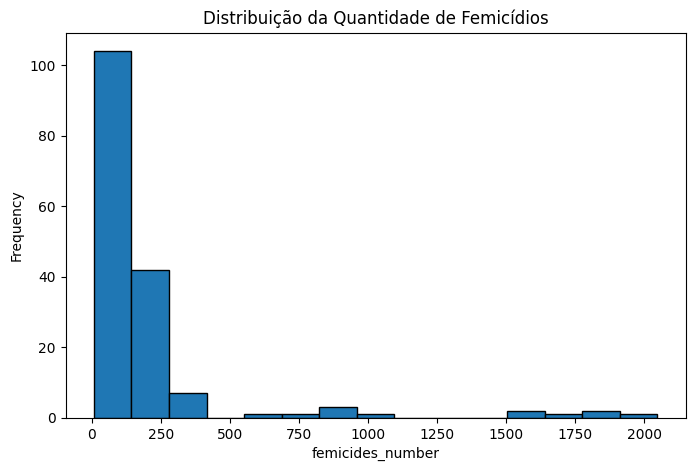

In [9]:
y.plot.hist(bins=15, edgecolor='black', figsize=(8, 5))
plt.xlabel('femicides_number')
plt.title('Distribuição da Quantidade de Femicídios')
plt.show()

Este histograma ilustra a frequência e a assimetria na distribuição do número absoluto de feminicídios (``femicides_number``) entre os países e anos presentes na base de dados.
A grande maioria das observações está concentrada na primeira barra (entre 0 e 250 casos).

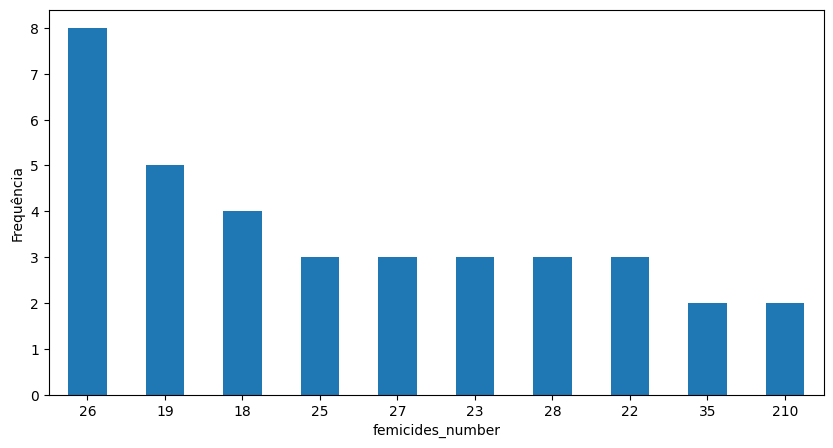

In [10]:
# Mostra apenas os 10 valores mais frequentes
y.value_counts().head(10).plot.bar(figsize=(10, 5))
plt.xticks(rotation=0)
plt.xlabel('femicides_number')
plt.ylabel('Frequência')
plt.show()

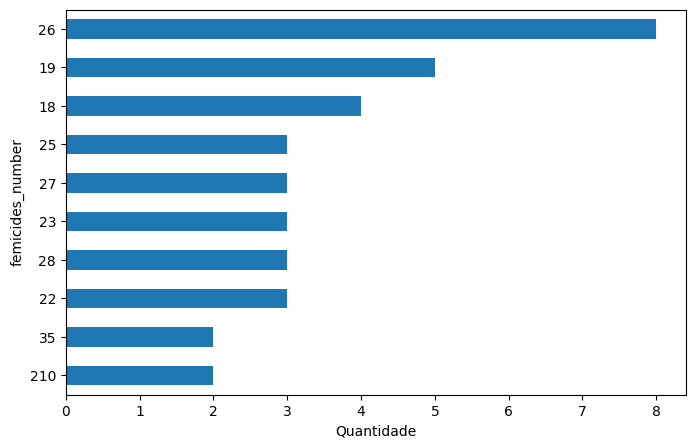

In [11]:
y.value_counts().head(10).plot.barh(figsize=(8, 5)).invert_yaxis()
plt.xlabel('Quantidade')
plt.ylabel('femicides_number')
plt.show()

O gráfico de barras exibe os 10 valores numéricos mais recorrentes para a contagem de feminicídios. O valor 26 é o mais frequente, aparecendo 8 vezes na base, seguido por valores como 19 (5 vezes) e 18 (4 vezes).

Podemos observar que a grande maioria dos países possui um **baixo** número de feminicídios por ano.. Na visão simplificada da coluna, é possível observar com maior frequência o valor `Baixo`. Isso leva a pensar que todos, ou pelo menos a maior parte dos valores, pertence justamente à classe `Baixa`, enquanto a frequência da classe `Alta` é muito menor, ou seja, `Baixa >> Alta`.

Uma possível explicação para o grande número de países classificados com poucos feminicídios pode estar relacionada às diferenças populacionais entre os países, à existência de políticas públicas de prevenção e combate à violência contra a mulher, à eficiência dos sistemas de segurança e registro de ocorrências e também às diferenças na forma como os casos são identificados e contabilizados. Portanto, um número baixo de registros não significa necessariamente que a violência contra a mulher seja inexistente ou menor, pois também pode haver casos não registrados ou diferenças nos critérios de classificação.

Imagine o seguinte cenário: eu tenho vários dados do DataFrame, entretanto desejo prever apenas o número de feminicídios e, para isso, utilizo conceitos de aprendizado de máquina. A maioria dos dados pertence à classe `Baixa`, enquanto uma parcela menor pertence à classe `Alta`. Isso significa que há uma grande possibilidade de ocorrer **viés**, pois números baixos representam a **Classe Majoritária** e números altos representam a **Classe Minoritária**. Essa diferença na quantidade de exemplos entre as classes pode causar um **desbalanceamento dos dados**, fazendo com que alguns modelos tenham maior tendência a prever a classe majoritária e apresentem dificuldade para identificar corretamente os países com valores altos de feminicídios.


## Principais estratégias de balanceamento

* **Undersampling:** estratégia que reduz a quantidade de exemplos da **classe majoritária**, deixando a distribuição entre as classes mais equilibrada. Apesar de ser simples e eficiente em conjuntos de dados muito grandes, pode resultar na perda de informações importantes.

* **Oversampling:** técnica que aumenta a quantidade de exemplos da **classe minoritária**. Isso pode ser feito duplicando exemplos existentes ou criando novos exemplos sintéticos.

* **Uso de Algoritmos Sensíveis ao Desbalanceamento:** alguns algoritmos e modelos possuem métodos que permitem dar **maior importância à classe minoritária** durante o treinamento. Dessa forma, é possível reduzir o efeito do desbalanceamento sem precisar alterar diretamente os dados originais.


## Uso de Algoritmos Sensíveis ao Desbalanceamento

Uma estratégia para lidar com dados desbalanceados é utilizar algoritmos que permitem dar mais importância à **classe minoritária** durante o treinamento. Entre eles estão as **Árvores de Decisão** e a **Floresta Aleatória (Random Forest)**.

Neste caso, usaremos uma **Random Forest**. Podemos utilizar o parâmetro `class_weight` para atribuir um peso maior à classe minoritária. Dessa forma, o modelo dá mais importância aos erros cometidos nessa classe durante o treinamento, o que pode melhorar sua capacidade de identificá-la.

Definimos os atributos(``features``) e o alvo(``target``)

In [12]:
ATRIBUTOS = ["gpi", "le_f", "mmr"]
TARGET_BINARIO = "alto_risco"

Criamos um DataFrame contendo apenas os atributos que serão utilizados no modelo. Em seguida, iremos criar uma nova coluna para **binarizar os dados**, separando os valores em duas categorias: onde **1** representa países com taxa de feminicídio ``acima da mediana regional`` e **0** representa países ``abaixo da mediana``

In [13]:
# Calculando a taxa por 100 mil mulheres
df_sem_faltantes['taxa_feminicidio_100k'] = (df_sem_faltantes['femicides_number']/df_sem_faltantes['fem_pop']) * 100000

# Binarização baseada na taxa (como limite vamos usar a mediana das taxas)
limite_taxa = df_sem_faltantes['taxa_feminicidio_100k'].median()
df_sem_faltantes['alto_risco'] = (df_sem_faltantes['taxa_feminicidio_100k'] >= limite_taxa).astype(int)


In [14]:
df_novo = df_sem_faltantes.reindex(ATRIBUTOS + [TARGET_BINARIO], axis=1).copy()

Para avaliar a capacidade de generalização do modelo de forma justa, dividimos o conjunto de dados em dois grupos independentes.

Reservamos 30% dos dados para o conjunto de teste e 70% para o treino; Usamos uma semente aleatória para garantir que os resultados sejam exatamente os mesmos a cada execução.

In [15]:
#definindo o split teste e treino
TAMANHO_TESTE = 0.25
SEMENTE_ALEATORIA = 67

Instanciamos e treinamos um classificador de Floresta Aleatória.

Parâmetros Principais:
- n_estimators=100: Constrói um conjunto formado por 100 árvores de decisão.

- ``class_weight='balanced'``: Ajusta automaticamente os pesos das classes inversamente proporcionais às suas frequências, compensando o desbalanceamento dos dados.

- n_jobs=4: Paraleliza o processamento utilizando 4 núcleos de CPU para acelerar o treinamento.

Como a distribuição das classes é desbalanceada, o parâmetro ``stratify`` garante que a proporção entre as classes 0 e 1 seja mantida proporcionalmente tanto no treino quanto no teste.

In [16]:
indices = df_novo.index
indices_treino, indices_teste = train_test_split(
    indices, 
    test_size=TAMANHO_TESTE, 
    random_state=SEMENTE_ALEATORIA,
    stratify=df_novo[TARGET_BINARIO]#proporção desbalanceada
)

In [17]:
modelo_fa = RandomForestClassifier()

In [18]:
df_treino = df_novo.loc[indices_treino]
df_teste = df_novo.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino[TARGET_BINARIO].values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste[TARGET_BINARIO].values.ravel()

print(f"Distribuição de classes no Treino: {np.bincount(y_treino)}")
print(f"Distribuição de classes no Teste: {np.bincount(y_teste)}")

Distribuição de classes no Treino: [61 62]
Distribuição de classes no Teste: [21 21]


Com ``class_weight='balanced'``o modelo passa a considerar a distribuição das classes ao treinar, ajudando a melhorar a previsão da classe minoritária.

O ajuste de Pesos (``Class Weight``), em vez de alterar os dados, modificamos a função de custo do algoritmo. A penalidade para o erro na classe $c$ é ponderada por:
  $$
  w_c = \frac{N}{K \cdot N_c}
  $$
Onde $N$ é o total de amostras, $K$ é o número de classes e $N_c$ é a quantidade de amostras da classe $c$.

In [19]:
modelo_fa = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', 
    random_state=SEMENTE_ALEATORIA,
    n_jobs=4
)
modelo_fa.fit(X_treino, y_treino)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_previsto = modelo_fa.predict(X_teste)
y_probas = modelo_fa.predict_proba(X_teste)# retorna a probabilidade predita para cada classe, ao inves de apenas mostrar a class label.

print("Relatório de Classificação do Random Forest")
print(classification_report(y_teste, y_previsto))

Relatório de Classificação do Random Forest
              precision    recall  f1-score   support

           0       0.72      0.86      0.78        21
           1       0.82      0.67      0.74        21

    accuracy                           0.76        42
   macro avg       0.77      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



Visualizamos o impacto e a relevância de cada atributo na tomada de decisão das árvores do modelo.

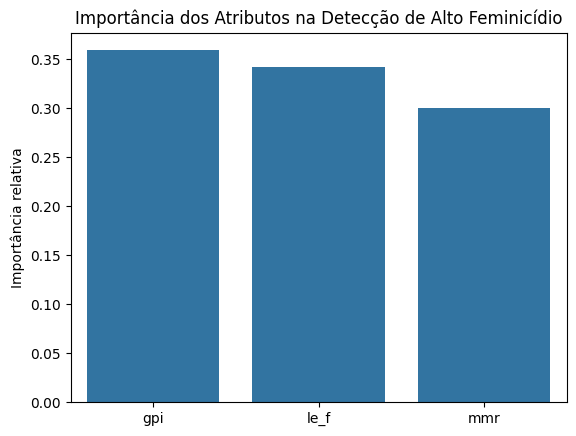

In [21]:
importancia = modelo_fa.feature_importances_

eixo = sns.barplot(x=ATRIBUTOS, y=importancia)
eixo.set_ylabel("Importância relativa")
eixo.set_title("Importância dos Atributos na Detecção de Alto Feminicídio")
plt.show()

O ganho relativo de impureza fornecido por cada variável de entrada no modelo de Floresta Aleatória.  Comportamento dos Dados: O índice gpi (Índice de Paridade de Gênero) lidera como a variável de maior peso, seguido pela taxa de mortalidade materna mmr e pela expectativa de vida feminina le_f. 
A visualização mostra que indicadores socioeconômicos de igualdade e saúde estrutural feminina têm poder preditivo equilibrado e relevante para discernir países com taxas de feminicídio acima ou abaixo da mediana regional.

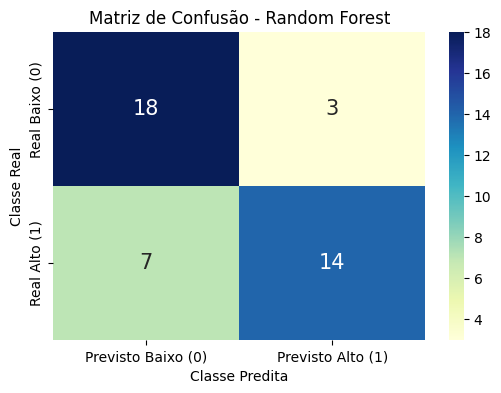

In [22]:
y_verdadeiro = y_teste
y_previsao = modelo_fa.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao)

df_conf = pd.DataFrame(matriz_conf, index=['Baixo Risco (0)', 'Alto Risco (1)'], 
                                   columns=['Previsto Baixo (0)', 'Previsto Alto (1)'])

plt.figure(figsize=(6, 4))
sns.heatmap(df_conf, annot=True, fmt='d', cmap='YlGnBu', annot_kws={"size": 15}, xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],)
plt.title("Matriz de Confusão - Random Forest")
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.show()

Analisamos detalhadamente os erros e acertos do modelo por meio de uma matriz de confusão e calculamos o percentual geral de acerto.

In [23]:
acuracia = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 76.19%


##  Reamostragem
A reamostragem é uma técnica que pode ser utilizada para equilibrar o conjunto de dados. Existem duas abordagens principais: undersampling e oversampling. No undersampling, você reduz o número de exemplos da classe majoritária. Já no oversampling, você aumenta o número de exemplos da classe minoritária.

**Balanceando o dataset**
Temos 2 classes:
- Classe majoritária: a que possui mais registros
- Classe minoritária: a que possui menos registros

Podemos balancear o dataset reduzindo os registros da classe majoritária (com mais registros) ou aumentando os registros da classe minoritária (com menos registros)

<div style="text-align:center;">
<img src="https://editor.analyticsvidhya.com/uploads/655570_FeIp1t4uEcW5LmSM.png" width="450" weight="450" 
</div>

### Undersampling

O **undersampling** consiste em selecionar apenas uma parte dos dados da **classe majoritária**, de forma que ela tenha aproximadamente a mesma quantidade de exemplos que a classe minoritária. Assim, a distribuição entre as classes fica mais equilibrada. Como são utilizados menos exemplos da classe majoritária, parte dos dados originais é descartada.

### Oversampling

O **oversampling** consiste em aumentar a quantidade de exemplos da **classe minoritária** até que ela tenha uma quantidade semelhante à da classe majoritária. Isso pode ser feito duplicando exemplos existentes ou criando novos exemplos sintéticos. Dessa forma, o conjunto de dados fica mais equilibrado sem precisar remover exemplos da classe majoritária.


### Undersampling

#### Reduzindo os registros da classe majoritária
Vamos retirar parte dos dados da classe que possui mais registros.
- É importante ter cuidado para não remover exemplos que contenham informações importantes para o modelo.
- Também precisamos verificar se a quantidade de dados restante é suficiente para realizar o treinamento.
- Uma forma simples de começar é remover registros **aleatoriamente** usando o **[RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)**.

Antes que nada é importante ter instalada a biblioteca: ``imbalanced-learn``

In [24]:
# Instalando a biblioteca
# !pip install -U imbalanced-learn

In [25]:
scaler = StandardScaler()
X_treino_us_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste) 

modelo_us = RandomUnderSampler(random_state=SEMENTE_ALEATORIA)
X_treino_us_scaled, y_treino_us = modelo_us.fit_resample(X_treino_us_scaled, y_treino)

In [26]:
# Avaliando com Regressão Logística
clf_rl_us = LogisticRegression(random_state=SEMENTE_ALEATORIA, max_iter=500)
clf_rl_us.fit(X_treino_us_scaled, y_treino_us)
y_predito_rl_us = clf_rl_us.predict(X_teste_scaled )

In [27]:
print("Undersampling na Regressão Logística")
print(f"Recall: {recall_score(y_teste, y_predito_rl_us):.2f}")
print(f"Precision: {precision_score(y_teste, y_predito_rl_us):.2f}")

Undersampling na Regressão Logística
Recall: 0.52
Precision: 0.65


<Axes: >

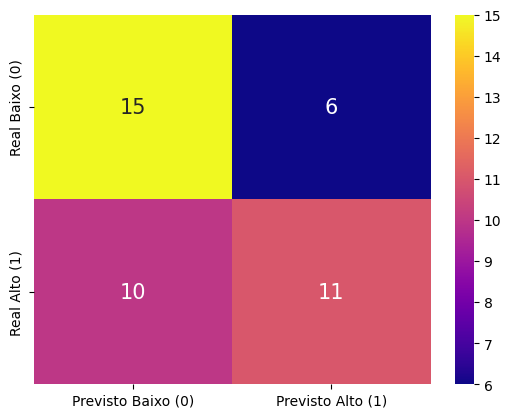

In [28]:
y_verdadeiro = y_teste
matriz_conf = confusion_matrix(y_verdadeiro, y_predito_rl_us)
df_conf = pd.DataFrame(matriz_conf)

sns.heatmap(df_conf,annot=True,annot_kws={"size": 15},cmap="plasma", xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],)

In [29]:
# Avaliando com Árvore de Decisão
clf_dt_us = DecisionTreeClassifier(random_state=SEMENTE_ALEATORIA)
clf_dt_us.fit(X_treino_us_scaled, y_treino_us)
y_predito_ad_us = clf_dt_us.predict(X_teste_scaled)

In [30]:
print("Undersampling na Árvore de Decisão")
print(f"Recall: {recall_score(y_teste, y_predito_ad_us):.2f}")
print(f"Precision: {precision_score(y_teste, y_predito_ad_us):.2f}")

Undersampling na Árvore de Decisão
Recall: 0.62
Precision: 0.81


<Axes: >

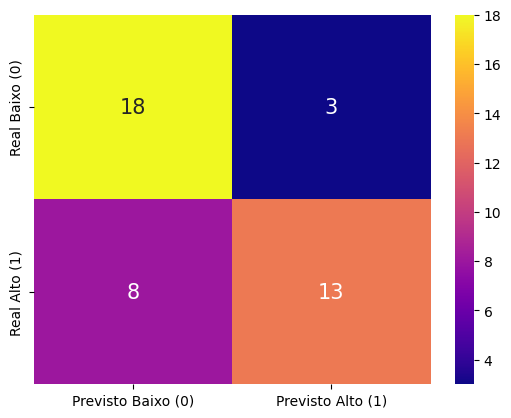

In [31]:
y_verdadeiro = y_teste
matriz_conf = confusion_matrix(y_verdadeiro, y_predito_ad_us)
df_conf = pd.DataFrame(matriz_conf)

sns.heatmap(df_conf,annot=True,annot_kws={"size": 15},cmap="plasma", xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],)

### Oversampling

#### Aumentando os registros da classe minoritária
- Duplicando os valores de maneira aleatória com o **[RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)**
- Precisamos garantir que não vamos ter overfitting por mostrar ao modelo várias vezes os mesmos dados

In [32]:
# Importando o RandomOverSampler do imblearn
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

modelo_os = RandomOverSampler(random_state=SEMENTE_ALEATORIA)
X_treino_os_scaled, y_treino_os = modelo_os.fit_resample(X_treino_scaled, y_treino)

In [33]:
clf_rl_os = LogisticRegression(random_state=SEMENTE_ALEATORIA, max_iter=500)
clf_rl_os.fit(X_treino_os_scaled, y_treino_os)

y_predito_rl_os = clf_rl_os.predict(X_teste_scaled)

In [34]:
print("Oversampling na Regressão Logística")
print(f"Recall: {recall_score(y_teste, y_predito_rl_os):.2f}")
print(f"Precision: {precision_score(y_teste, y_predito_rl_os):.2f}")

Oversampling na Regressão Logística
Recall: 0.52
Precision: 0.65


<Axes: >

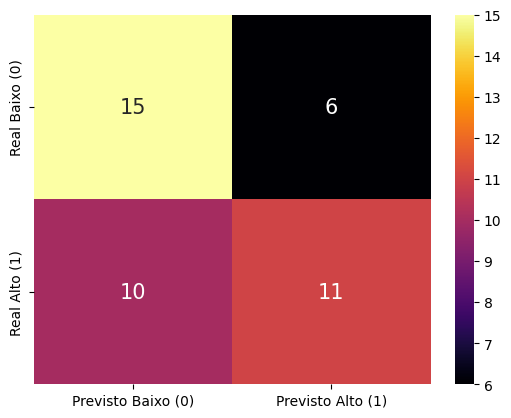

In [35]:
y_verdadeiro = y_teste
matriz_conf = confusion_matrix(y_verdadeiro, y_predito_rl_os)
df_conf = pd.DataFrame(matriz_conf)

sns.heatmap(df_conf,annot=True,annot_kws={"size": 15},cmap="inferno", xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],)

In [36]:
# Avaliando com Árvore de Decisão
clf_ad_os = DecisionTreeClassifier(random_state=SEMENTE_ALEATORIA)
clf_ad_os.fit(X_treino_os_scaled, y_treino_os)
y_predito_ad_os = clf_ad_os.predict(X_teste_scaled)

In [37]:
print("Oversampling na Árvore de Decisão")
print(f"Recall: {recall_score(y_teste, y_predito_ad_os):.2f}")
print(f"Precision: {precision_score(y_teste, y_predito_ad_os):.2f}")

Oversampling na Árvore de Decisão
Recall: 0.52
Precision: 0.85


<Axes: >

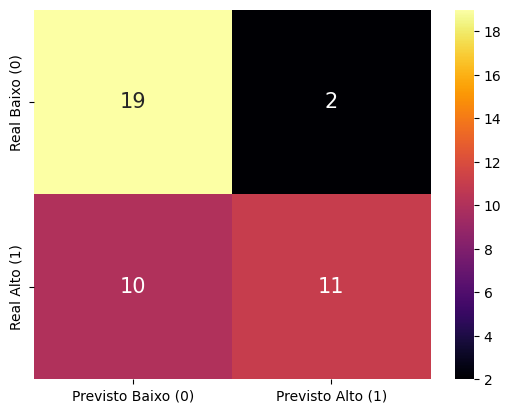

In [38]:
y_verdadeiro = y_teste
matriz_conf = confusion_matrix(y_verdadeiro, y_predito_ad_os)
df_conf = pd.DataFrame(matriz_conf)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 15}, cmap="inferno", xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],)

**Também existem várias outras formas de fazermos o undersampling e o oversampling e todas elas são explicadas na própria documentação**<br>
- Undersampling:
    - https://imbalanced-learn.org/stable/references/under_sampling.html
- Oversampling:
    - https://imbalanced-learn.org/stable/references/over_sampling.html

## Comparando com baseline

Um modelo mais simples chamado de **modelo de base** ou **baseline**. 

Este é o tipo de modelo que chamamos de *dummy*, *baseline*, linha de base ou modelo fictício. Trata-se de um modelo muito simples que podemos usar para comparar o desempenho de modelos mais complexos. Qualquer modelo com desempenho *pior* que um modelo baseline é um modelo considerado muito ruim.

In [39]:
modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino)

,strategy,'prior'
,random_state,None
,constant,None


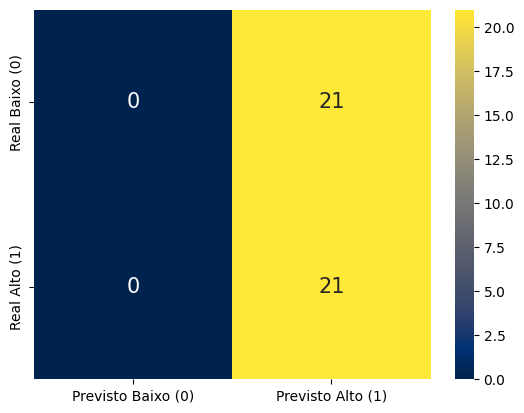

In [40]:
y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao)
df_conf = pd.DataFrame(matriz_conf)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 15}, cmap="cividis", xticklabels=['Previsto Baixo (0)', 'Previsto Alto (1)'],
    yticklabels=['Real Baixo (0)', 'Real Alto (1)'],);

In [41]:
acuracia = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 50.00%


## Discussão comparativa entre algoritmos

Para compreender melhor o desempenho dos modelos, é importante comparar os algoritmos utilizados com outras abordagens estudadas na disciplina. Cada algoritmo possui uma forma diferente de aprender os padrões dos dados, o que influencia sua capacidade de classificação, interpretação e generalização.

| Algoritmo               | Como funciona                                                                                                | Principais características                                     | Vantagens                                                                                                                                             | Limitações                                                                                        |
| ----------------------- | ------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| **Árvore de Decisão**   | Cria uma sequência de regras dividindo os dados em diferentes regiões.                                       | Modelo baseado em regras e divisões sucessivas.                | Fácil de interpretar e visualizar, consegue representar relações não lineares.                                                                        | Pode sofrer **overfitting**, principalmente quando a árvore cresce muito.                         |
| **Random Forest**       | Treina várias árvores de decisão de forma independente e combina suas previsões.                             | Conjunto de árvores; reduz a variância do modelo. | Geralmente apresenta boa generalização, é robusta a ruídos e pode utilizar `class_weight='balanced'` para dar maior importância à classe minoritária. | É menos interpretável que uma única árvore e pode exigir mais recursos computacionais.            |
| **Regressão Logística** | Calcula a probabilidade de uma observação pertencer a uma classe usando uma combinação linear das variáveis. | Modelo linear baseado nos *log-odds*.                          | Simples, rápido e fácil de interpretar; funciona bem como modelo de referência (*baseline*).                                                          | Tem dificuldade para representar relações altamente não lineares sem transformação das variáveis. |
| **Baseline**            | Representa uma estratégia simples usada como referência para avaliar os modelos.                             | Serve como ponto de comparação.                                | Permite verificar se os modelos de Machine Learning realmente melhoram o desempenho em relação a uma estratégia simples.                              | Não busca aprender relações complexas nos dados.                                                  |


A ``Árvore de Decisão`` pode ser considerada a estrutura básica da Random Forest. Entretanto, enquanto uma única árvore pode apresentar alta variância e sofrer overfitting, a combinação de várias árvores tende a produzir um modelo mais estável.

Já a ``Regressão Logística`` possui uma abordagem diferente, pois procura estabelecer uma relação matemática entre as variáveis de entrada e a probabilidade de cada classe. Por isso, ela pode funcionar como um **baseline**, permitindo verificar se modelos mais complexos, como Random Forest, realmente conseguem obter ganhos de desempenho.

A comparação entre os algoritmos não deve considerar apenas qual modelo apresentou a maior métrica. É importante observar também **como cada algoritmo aprende, quais tipos de relações consegue representar, sua sensibilidade ao overfitting, sua interpretabilidade e seu comportamento diante de dados desbalanceados**.

## Referências

ANALYTICS VIDHYA. **Top 5 favorite statistical concepts**. Analytics Vidhya, 2020. Disponível em: https://www.analyticsvidhya.com/blog/2020/11/top-5-favorite-statistical-concepts/. Acesso em: 13 set. 2026.

CONCEITOS.TECH. **Como lidar com dados desbalanceados em Machine Learning**. Conceitos Tech, [s.d.]. Disponível em: https://conceitos.tech/tutoriais/inteligencia-artificial/machine-learning/como-lidar-com-dados-desbalanceados-em-machine-learning/. Acesso em: 13 set. 2026.

IBM. **O que é ajuste de hiperparâmetros?** IBM Think, [s.d.]. Disponível em: https://www.ibm.com/br-pt/think/topics/hyperparameter-tuning. Acesso em: 13 set. 2026.

MARIO FILHO. **Precisão, recall e F1-score em Machine Learning**. Mario Filho, [s.d.]. Disponível em: https://mariofilho.com/precisao-recall-e-f1-score-em-machine-learning/. Acesso em: 13 set. 2026.

MARIO FILHO. **XGBoost e dados desbalanceados**. Mario Filho, [s.d.]. Disponível em: https://mariofilho.com/xgboost-dados-desbalanceados/. Acesso em: 13 set. 2026.

PROFISSÃO BIOTEC. **Dados desbalanceados: ensinando seu modelo da maneira certa a aprender**. Profissão Biotec, [s.d.]. Disponível em: https://profissaobiotec.com.br/dados-desbalanceados-ensinando-seu-modelo-maneira-certa-aprender/. Acesso em: 13 set. 2026.

REGUERIN, Nataly. **Latin America femicides and maternal mortality**. Kaggle, [s.d.]. Disponível em: https://www.kaggle.com/datasets/natalyreguerin/latin-america-femicides-and-maternal-mortality. Acesso em: 13 set. 2026.

MATPLOTLIB. **Colormaps in Matplotlib**. Matplotlib, [s.d.]. Disponível em: https://matplotlib.org/stable/users/explain/colors/colormaps.html. Acesso em: 13 set. 2026.


## Sobre a interação com IA

No desenvolvimento deste trabalho, utilizei ferramentas de inteligência artificial generativa como assistente de suporte. A IA auxiliou na formatação das células em Markdown, Revisão Textual: Correção ortográfica, gramatical e refinamento da fluidez textual da introdução e das explicações metodológicas. Esclarecimento Teórico: Suporte na formulação da explicação didática.
A responsabilidade pela realização do trabalho é inteiramente do aluno, a IA foi utilizada para complementação com revisão e adaptação do autor.